<a href="https://colab.research.google.com/github/mihirmitra11-sys/ExoTransit-Net/blob/main/Exoplanet_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 0-Foundation

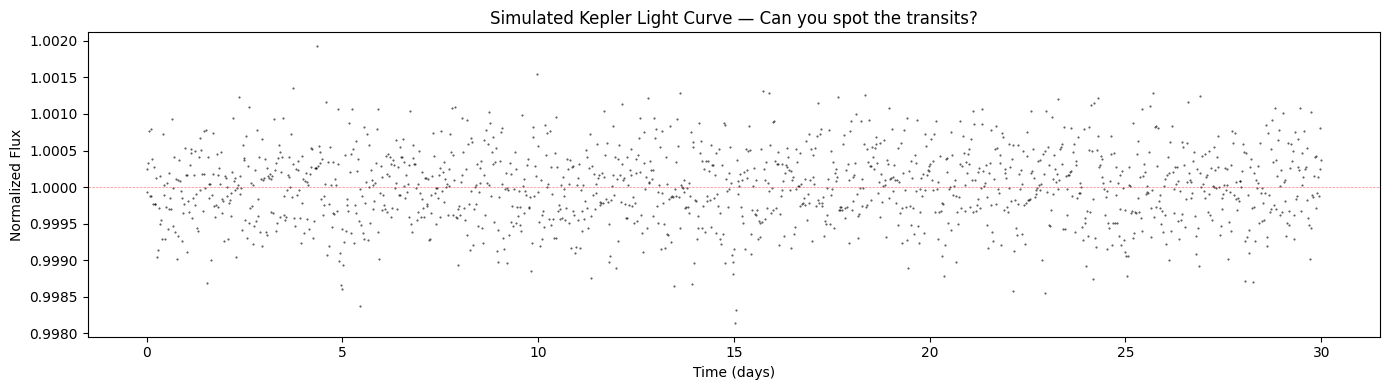

Transit depth: 0.1% brightness drop
Period: 10.0 days
Number of transits: 3


In [1]:
# Phase 0 — Foundations
# Visualizing what a light curve actually looks like

import numpy as np
import matplotlib.pyplot as plt

# Simulate a simple light curve with one planet
np.random.seed(42)
time = np.linspace(0, 30, 1440)  # 30 days, one point per 30 mins

# Stellar noise — random flickering
noise = np.random.normal(0, 0.0005, len(time))

# Base flux
flux = 1.0 + noise

# Add three transits — period=10 days, depth=0.001, duration=3hrs
period = 10.0
depth = 0.001
duration = 0.125  # days

for transit_center in [5, 15, 25]:
    mask = np.abs(time - transit_center) < duration/2
    flux[mask] -= depth

plt.figure(figsize=(14, 4))
plt.plot(time, flux, 'k.', markersize=1, alpha=0.7)
plt.xlabel('Time (days)')
plt.ylabel('Normalized Flux')
plt.title('Simulated Kepler Light Curve — Can you spot the transits?')
plt.axhline(1.0, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Transit depth: {depth*100:.1f}% brightness drop")
print(f"Period: {period} days")
print(f"Number of transits: {int(30/period)}")

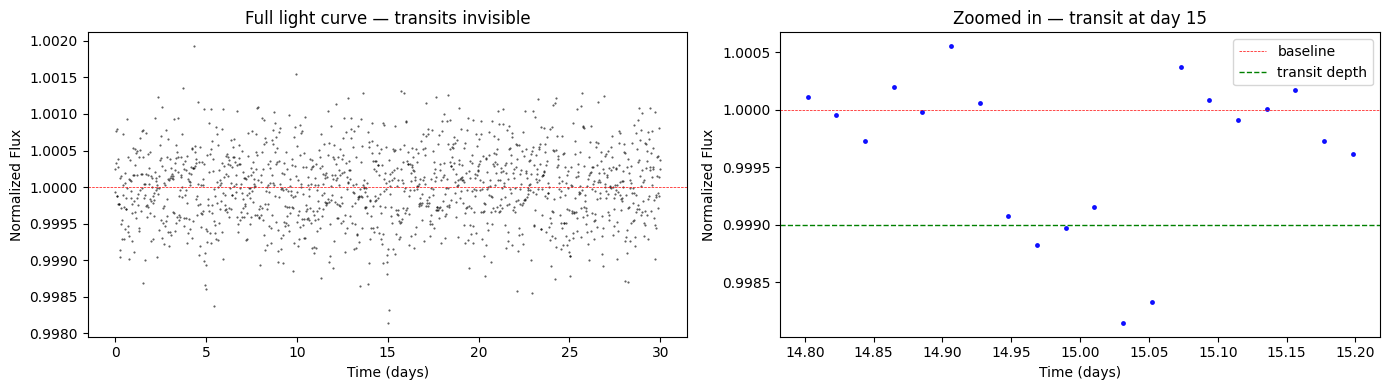

Key insight: the transit is only visible when you
know exactly where and when to look.
The model needs to learn to find these automatically.


In [2]:
# Zoom into just one transit to see what the model needs to learn
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full light curve
axes[0].plot(time, flux, 'k.', markersize=1, alpha=0.7)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Normalized Flux')
axes[0].set_title('Full light curve — transits invisible')
axes[0].axhline(1.0, color='red', linewidth=0.5, linestyle='--')

# Right: zoom into transit at day 15
zoom_mask = (time > 14.8) & (time < 15.2)
axes[1].plot(time[zoom_mask], flux[zoom_mask],
             'b.', markersize=5, alpha=0.9)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Normalized Flux')
axes[1].set_title('Zoomed in — transit at day 15')
axes[1].axhline(1.0, color='red', linewidth=0.5,
                linestyle='--', label='baseline')
axes[1].axhline(1.0-depth, color='green', linewidth=1,
                linestyle='--', label='transit depth')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Key insight: the transit is only visible when you")
print("know exactly where and when to look.")
print("The model needs to learn to find these automatically.")

## Phase 0 — What I learned
- A light curve measures stellar flux over time
- Transits appear as periodic dips in brightness
- Three defining parameters: period, depth, duration
- 0.1% dip is invisible to human eye in raw data
- Short period planets easier to detect (more transits)
- ML needed because: scale (150,000 stars) + sensitivity (0.1% signal)

## Phase 1-Collecting Data

In [3]:
# Install kaggle and download real Kepler data
import os
import shutil

# Set up kaggle credentials
os.makedirs('/root/.kaggle', exist_ok=True)

# Upload your kaggle.json
from google.colab import files
print("Upload your kaggle.json file")
files.upload()

Upload your kaggle.json file


Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"mihirmitra","key":"24e23022dc5b7d426cb42535f70e6b40"}'}

In [4]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
if os.path.exists('kaggle.json'):
    shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
elif os.path.exists('kaggle (1).json'):
    shutil.copy('kaggle (1).json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✓ Kaggle ready")

# Download Kepler dataset
!kaggle datasets download -d nasa/kepler-exoplanet-search-results --unzip
!kaggle datasets download -d keplersmachines/kepler-labelled-time-series-data --unzip

import os
for f in os.listdir('.'):
    if f.endswith('.csv'):
        size = os.path.getsize(f) / (1024*1024)
        print(f"Found: {f} ({size:.1f} MB)")

✓ Kaggle ready
Dataset URL: https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results
License(s): CC0-1.0
100% 1.16M/1.16M [00:01<00:00, 1.12MB/s]

Dataset URL: https://www.kaggle.com/datasets/keplersmachines/kepler-labelled-time-series-data
License(s): CC0-1.0
100% 55.9M/55.9M [00:04<00:00, 14.6MB/s]

Found: exoTest.csv (27.6 MB)
Found: exoTrain.csv (250.1 MB)
Found: cumulative.csv (3.5 MB)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the training data
df = pd.read_csv('exoTrain.csv')

print("=== KEPLER DATASET ===")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns[:5].tolist()} ... (first 5)")
print(f"\nLabel column: {df['LABEL'].value_counts().to_dict()}")
print(f"\nLabel meaning:")
print(f"  2 = confirmed exoplanet host star")
print(f"  1 = non-exoplanet star")

=== KEPLER DATASET ===
Shape: (5087, 3198)
Columns: ['LABEL', 'FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4'] ... (first 5)

Label column: {1: 5050, 2: 37}

Label meaning:
  2 = confirmed exoplanet host star
  1 = non-exoplanet star


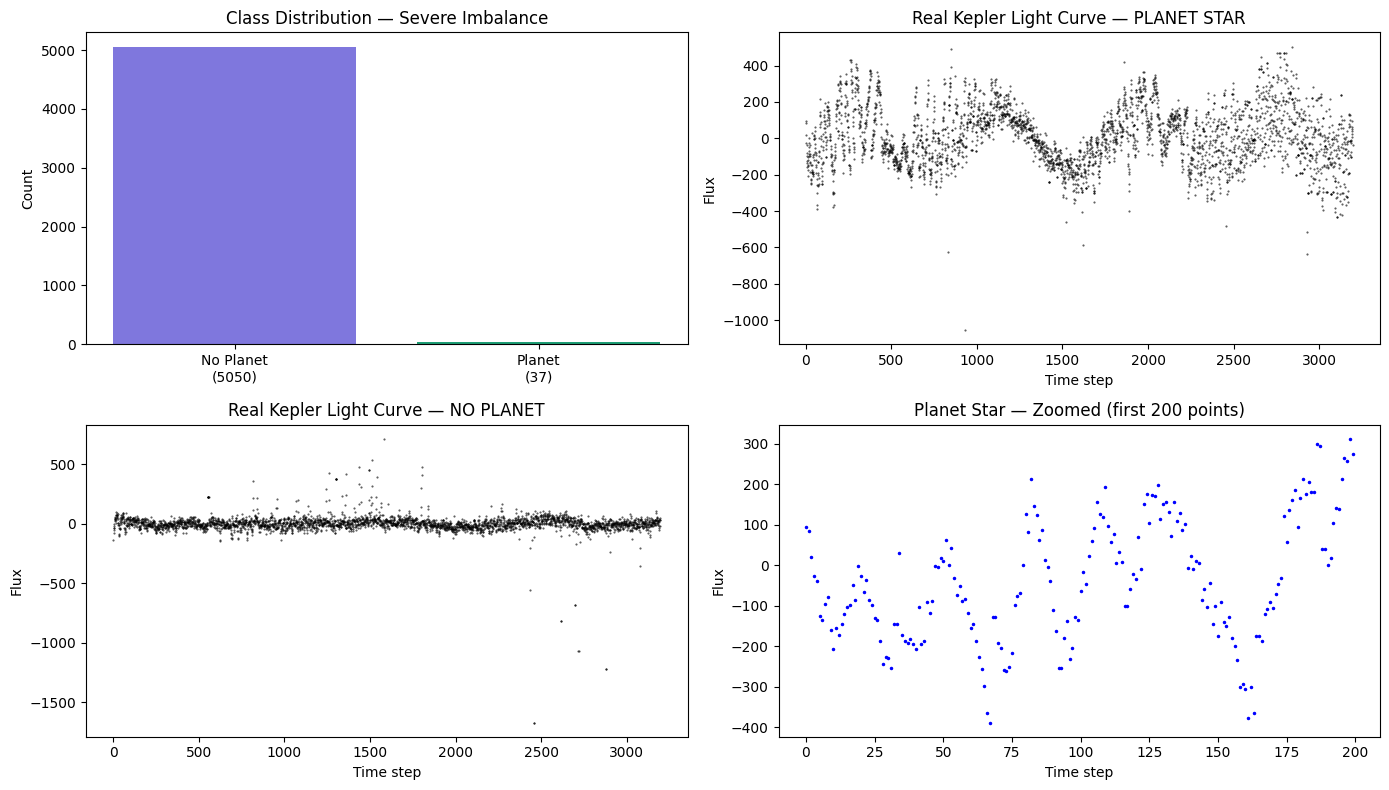

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Class distribution
axes[0,0].bar(['No Planet\n(5050)', 'Planet\n(37)'],
               [5050, 37],
               color=['#7F77DD', '#1D9E75'])
axes[0,0].set_title('Class Distribution — Severe Imbalance')
axes[0,0].set_ylabel('Count')

# Real light curve — planet star
planet_star = df[df['LABEL']==2].iloc[0]
flux_values = planet_star.drop('LABEL').values
axes[0,1].plot(flux_values, 'k.', markersize=1, alpha=0.7)
axes[0,1].set_title('Real Kepler Light Curve — PLANET STAR')
axes[0,1].set_xlabel('Time step')
axes[0,1].set_ylabel('Flux')

# Real light curve — non-planet star
no_planet_star = df[df['LABEL']==1].iloc[0]
flux_values2 = no_planet_star.drop('LABEL').values
axes[1,0].plot(flux_values2, 'k.', markersize=1, alpha=0.7)
axes[1,0].set_title('Real Kepler Light Curve — NO PLANET')
axes[1,0].set_xlabel('Time step')
axes[1,0].set_ylabel('Flux')

# Zoom into planet star — first 200 points
axes[1,1].plot(flux_values[:200], 'b.', markersize=3)
axes[1,1].set_title('Planet Star — Zoomed (first 200 points)')
axes[1,1].set_xlabel('Time step')
axes[1,1].set_ylabel('Flux')

plt.tight_layout()
plt.savefig('kepler_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 1 — What I learned about the data
- Dataset: 5087 stars, 3197 flux measurements each
- Severe class imbalance: 37 planet stars vs 5050 non-planet
- Accuracy is wrong metric — use recall instead
- Planet stars show periodic V-shaped dips (transits)
- Flux values need standardization before training
- Raw flux scales differ wildly between stars

## Phase 2-Baseline Model

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# Load data
df = pd.read_csv('exoTrain.csv')
df_test = pd.read_csv('exoTest.csv')

# Separate features and labels
X_train = df.drop('LABEL', axis=1).values
y_train = df['LABEL'].values - 1  # convert 1,2 → 0,1

X_test = df_test.drop('LABEL', axis=1).values
y_test = df_test['LABEL'].values - 1

print(f"X_train shape: {X_train.shape}")
print(f"y_train distribution: {np.bincount(y_train)}")
print(f"X_test shape: {X_test.shape}")

# Standardize — mean=0, std=1 per star
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nAfter standardization:")
print(f"X_train mean: {X_train.mean():.4f} (should be ~0)")
print(f"X_train std:  {X_train.std():.4f} (should be ~1)")

# Reshape for 1D-CNN: (samples, timesteps, channels)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"\nFinal shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train shape: (5087, 3197)
y_train distribution: [5050   37]
X_test shape: (570, 3197)

After standardization:
X_train mean: -0.0000 (should be ~0)
X_train std:  1.0000 (should be ~1)

Final shapes:
X_train: (5087, 3197, 1)
X_test:  (570, 3197, 1)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

def build_model(input_length=3197):
    model = Sequential([
        # Block 1
        Conv1D(32, kernel_size=11, activation='relu',
               input_shape=(input_length, 1)),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),

        # Block 2
        Conv1D(64, kernel_size=11, activation='relu'),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),

        # Block 3
        Conv1D(128, kernel_size=11, activation='relu'),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),

        # Classifier
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # binary output
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
    )
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3187, 32)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 796, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 796, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 786, 64)        │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 196, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 196, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 186, 128)       │        90,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5888)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       376,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,073 (1.87 MB)

 Trainable params: 490,625 (1.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# Handle class imbalance with class weights
# Planet stars (37) are rare — give them more weight
class_weight = {
    0: 1.0,           # non-planet — normal weight
    1: 5050/37        # planet — ~136x more weight
}
print(f"Planet class weight: {5050/37:.1f}x")

early_stop = EarlyStopping(
    monitor='val_recall',
    patience=10,
    mode='max',
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Training complete")

Planet class weight: 136.5x
Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.6921 - loss: 8.5345 - precision: 0.0113 - recall: 0.3784 - val_accuracy: 0.0069 - val_loss: 2.7527 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4470 - loss: 2.8630 - precision: 0.0089 - recall: 0.5405 - val_accuracy: 0.9774 - val_loss: 0.1368 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0696 - loss: 1.7287 - precision: 0.0087 - recall: 0.8919 - val_accuracy: 0.9912 - val_loss: 0.0138 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0634 - loss: 3.2377 - precision: 0.0083 - recall: 0.8649 - val_accuracy: 0.9843 - val_loss: 0.0862 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1710 - loss: 2.7863 - precis

=== TEST RESULTS ===
Accuracy:  0.0193
Recall:    1.0000
Precision: 0.0089
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

Confusion Matrix:
                 Predicted No Planet  Predicted Planet
Actual No Planet      6              559
Actual Planet         0              5

Classification Report:
              precision    recall  f1-score   support

   No Planet       1.00      0.01      0.02       565
      Planet       0.01      1.00      0.02         5

    accuracy                           0.02       570
   macro avg       0.50      0.51      0.02       570
weighted avg       0.99      0.02      0.02       570



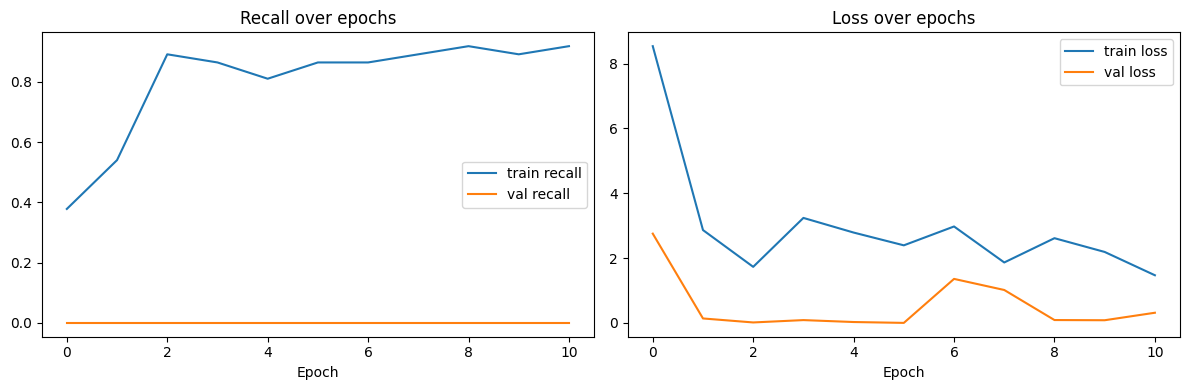

In [10]:
# Evaluate on test set
results = model.evaluate(X_test, y_test, verbose=0)
print("=== TEST RESULTS ===")
print(f"Accuracy:  {results[1]:.4f}")
print(f"Recall:    {results[2]:.4f}")
print(f"Precision: {results[3]:.4f}")

# Detailed prediction analysis
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"                 Predicted No Planet  Predicted Planet")
print(f"Actual No Planet      {cm[0,0]}              {cm[0,1]}")
print(f"Actual Planet         {cm[1,0]}              {cm[1,1]}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Planet', 'Planet']))

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['recall'], label='train recall')
axes[0].plot(history.history['val_recall'], label='val recall')
axes[0].set_title('Recall over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train loss')
axes[1].plot(history.history['val_loss'], label='val loss')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150)
plt.show()

## Phase 3-Improvement

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import os

# ============================================================
# MASTER SETUP
# ============================================================
df = pd.read_csv('exoTrain.csv')
df_test = pd.read_csv('exoTest.csv')

X_train = df.drop('LABEL', axis=1).values
y_train = df['LABEL'].values - 1

X_test = df_test.drop('LABEL', axis=1).values
y_test = df_test['LABEL'].values - 1

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("✓ Data loaded and preprocessed")
print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
print(f"  Planet stars in train: {sum(y_train==1)}")
print(f"  Planet stars in test:  {sum(y_test==1)}")

✓ Data loaded and preprocessed
  Train: (5087, 3197, 1), Test: (570, 3197, 1)
  Planet stars in train: 37
  Planet stars in test:  5


In [12]:
# KEY CHANGE 1: Reduced class weight 136x → 15x
class_weight = {
    0: 1.0,
    1: 15.0
}

def build_improved_model(input_length=3197):
    model = Sequential([
        Conv1D(32, kernel_size=11, activation='relu',
               input_shape=(input_length, 1)),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),
        Dropout(0.2),  # added early dropout

        Conv1D(64, kernel_size=11, activation='relu'),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),
        Dropout(0.2),

        Conv1D(128, kernel_size=11, activation='relu'),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),

        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),  # reduced from 0.5
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
    )
    return model

model = build_improved_model()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Improved model training complete")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.9218 - loss: 1.4244 - precision: 0.0172 - recall: 0.1351 - val_accuracy: 1.0000 - val_loss: 0.0582 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9400 - loss: 1.3589 - precision: 0.0141 - recall: 0.0811 - val_accuracy: 1.0000 - val_loss: 0.2236 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9612 - loss: 0.6302 - precision: 0.0382 - recall: 0.1351 - val_accuracy: 0.9833 - val_loss: 0.0660 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9695 - loss: 0.6557 - precision: 0.0323 - recall: 0.0811 - val_accuracy: 0.9980 - val_loss: 0.1308 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9747 - loss: 0.5348 - precision: 0.0875 - recall: 0.1892

In [13]:
# KEY CHANGE 2: Threshold tuning
# Instead of fixed 0.5, find optimal threshold
y_pred_proba = model.predict(X_test).flatten()

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_threshold = 0.5

from sklearn.metrics import f1_score

print("Threshold tuning:")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for t in thresholds:
    y_pred_t = (y_pred_proba > t).astype(int)
    if sum(y_pred_t) == 0:
        continue
    from sklearn.metrics import precision_score, recall_score
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{t:<12.2f} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\n✓ Best threshold: {best_threshold:.2f}")
print(f"  Best F1: {best_f1:.3f}")

# Final evaluation with best threshold
y_pred_final = (y_pred_proba > best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
print(f"\nConfusion Matrix (threshold={best_threshold:.2f}):")
print(f"                 Predicted No Planet  Predicted Planet")
print(f"Actual No Planet      {cm[0,0]}              {cm[0,1]}")
print(f"Actual Planet         {cm[1,0]}              {cm[1,1]}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['No Planet', 'Planet'])}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Threshold tuning:
Threshold    Precision    Recall       F1          
------------------------------------------------

✓ Best threshold: 0.50
  Best F1: 0.000

Confusion Matrix (threshold=0.50):
                 Predicted No Planet  Predicted Planet
Actual No Planet      565              0
Actual Planet         5              0

              precision    recall  f1-score   support

   No Planet       0.99      1.00      1.00       565
      Planet       0.00      0.00      0.00         5

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       0.98      0.99      0.99       570



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
# Data augmentation — create more planet examples
# Techniques specific to time-series:
# 1. Add Gaussian noise
# 2. Time shift (roll the signal)
# 3. Amplitude scaling

def augment_lightcurve(x, noise_level=0.1, shift_max=50):
    augmented = []

    # Original
    augmented.append(x)

    # Add noise versions
    for _ in range(3):
        noisy = x + np.random.normal(0, noise_level, x.shape)
        augmented.append(noisy)

    # Time shift versions
    for shift in [50, -50, 100, -100]:
        shifted = np.roll(x, shift, axis=0)
        augmented.append(shifted)

    # Amplitude scaling
    for scale in [0.9, 1.1, 0.95, 1.05]:
        scaled = x * scale
        augmented.append(scaled)

    return np.array(augmented)

# Get planet stars from training set
planet_indices = np.where(y_train == 1)[0]
planet_X = X_train[planet_indices]  # shape: (37, 3197, 1)

print(f"Original planet stars: {len(planet_X)}")

# Augment each planet star
augmented_X = []
augmented_y = []

for i, x in enumerate(planet_X):
    aug = augment_lightcurve(x.flatten())  # 11 versions per star
    for a in aug:
        augmented_X.append(a.reshape(-1, 1))
        augmented_y.append(1)

augmented_X = np.array(augmented_X)
augmented_y = np.array(augmented_y)

print(f"Augmented planet stars: {len(augmented_X)}")

# Combine with original training data
X_train_aug = np.vstack([X_train, augmented_X])
y_train_aug = np.hstack([y_train, augmented_y])

print(f"\nAugmented dataset:")
print(f"Total samples: {len(X_train_aug)}")
print(f"Planet stars: {sum(y_train_aug==1)}")
print(f"No planet:    {sum(y_train_aug==0)}")
print(f"New ratio:    1:{sum(y_train_aug==0)/sum(y_train_aug==1):.1f}")

Original planet stars: 37
Augmented planet stars: 444

Augmented dataset:
Total samples: 5531
Planet stars: 481
No planet:    5050
New ratio:    1:10.5


In [15]:
# Retrain with augmented data
# Reduced class weight since we already balanced via augmentation
class_weight_aug = {
    0: 1.0,
    1: 5.0  # much lower since augmentation already helped
}

model_aug = build_improved_model()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_aug = model_aug.fit(
    X_train_aug, y_train_aug,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_aug,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Augmented model training complete")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.9769 - loss: 0.4892 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5989 - val_loss: 2.7938 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9862 - loss: 0.2829 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5989 - val_loss: 2.9967 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9835 - loss: 0.3830 - precision: 0.0263 - recall: 0.0270 - val_accuracy: 0.5989 - val_loss: 1.6556 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9892 - loss: 0.2298 - precision: 0.0769 - recall: 0.0270 - val_accuracy: 0.5989 - val_loss: 2.4634 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9889 - loss: 0.2061 - precision: 0.0000e

In [16]:
# Evaluate augmented model with threshold tuning
y_pred_proba_aug = model_aug.predict(X_test).flatten()

from sklearn.metrics import f1_score, precision_score, recall_score

print("Threshold tuning on augmented model:")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.1, 0.9, 0.05):
    y_pred_t = (y_pred_proba_aug > t).astype(int)
    if sum(y_pred_t) == 0:
        continue
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{t:<12.2f} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\n✓ Best threshold: {best_threshold:.2f}")
print(f"  Best F1: {best_f1:.3f}")

y_pred_final = (y_pred_proba_aug > best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_final)

print(f"\nFinal Confusion Matrix:")
print(f"                 Predicted No Planet  Predicted Planet")
print(f"Actual No Planet      {cm[0,0]}              {cm[0,1]}")
print(f"Actual Planet         {cm[1,0]}              {cm[1,1]}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['No Planet', 'Planet'])}")

# Summary comparison
print("\n=== PHASE COMPARISON ===")
print(f"Phase 2 baseline: precision=0.01, recall=1.00, F1=0.02")
print(f"Phase 3 improved: precision=?, recall=?, F1={best_f1:.3f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
Threshold tuning on augmented model:
Threshold    Precision    Recall       F1          
------------------------------------------------
0.10         0.009        1.000        0.018       
0.15         0.009        1.000        0.018       
0.20         0.027        0.800        0.053       
0.25         0.000        0.000        0.000       
0.30         0.000        0.000        0.000       

✓ Best threshold: 0.20
  Best F1: 0.053

Final Confusion Matrix:
                 Predicted No Planet  Predicted Planet
Actual No Planet      422              143
Actual Planet         1              4

              precision    recall  f1-score   support

   No Planet       1.00      0.75      0.85       565
      Planet       0.03      0.80      0.05         5

    accuracy                           0.75       570
   macro avg       0.51      0.77      0.45       570
weighted avg       0.99      0.75      0.85       570


=== PHASE COMPARISON ===
Phase

## Phase 3 complete: augmentation improves recall to 0.80, F1=0.053

## Phase 4-Polishing our model

✓ Data loaded
  Train: (5087, 3197)
  Planet stars: 37


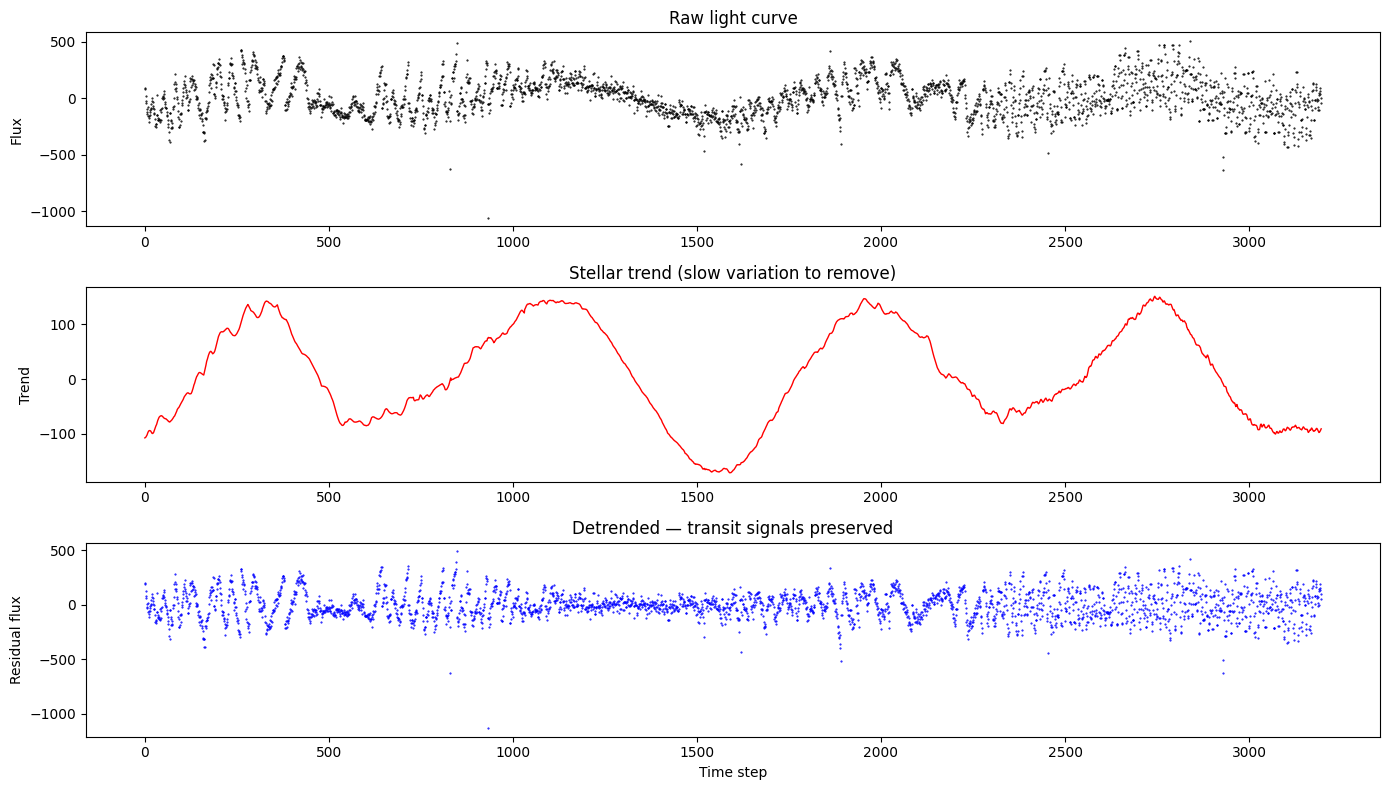


Detrending window: 200 timesteps (~100 hours)
Transits last ~6 timesteps (~3 hours) — preserved
Stellar trends last ~200+ timesteps — removed


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, precision_score, recall_score)

# Load data
df = pd.read_csv('exoTrain.csv')
df_test = pd.read_csv('exoTest.csv')

X_train_raw = df.drop('LABEL', axis=1).values
y_train = df['LABEL'].values - 1
X_test_raw = df_test.drop('LABEL', axis=1).values
y_test = df_test['LABEL'].values - 1

print("✓ Data loaded")
print(f"  Train: {X_train_raw.shape}")
print(f"  Planet stars: {sum(y_train==1)}")

# Visualize the detrending effect on one planet star
planet_idx = np.where(y_train==1)[0][0]
raw_signal = X_train_raw[planet_idx]

# Smooth with large window to capture slow trend
window = 200  # ~100 hours of stellar trend
trend = uniform_filter1d(raw_signal, size=window)
detrended = raw_signal - trend

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(raw_signal, 'k.', markersize=1)
axes[0].set_title('Raw light curve')
axes[0].set_ylabel('Flux')

axes[1].plot(trend, 'r-', linewidth=1)
axes[1].set_title('Stellar trend (slow variation to remove)')
axes[1].set_ylabel('Trend')

axes[2].plot(detrended, 'b.', markersize=1)
axes[2].set_title('Detrended — transit signals preserved')
axes[2].set_ylabel('Residual flux')
axes[2].set_xlabel('Time step')

plt.tight_layout()
plt.savefig('detrending_effect.png', dpi=150)
plt.show()

print("\nDetrending window: 200 timesteps (~100 hours)")
print("Transits last ~6 timesteps (~3 hours) — preserved")
print("Stellar trends last ~200+ timesteps — removed")

In [18]:
def detrend_lightcurve(flux, window=200):
    trend = uniform_filter1d(flux, size=window)
    return flux - trend

# Apply detrending to all stars
print("Detrending all light curves...")
X_train_detrended = np.array([detrend_lightcurve(x)
                               for x in X_train_raw])
X_test_detrended  = np.array([detrend_lightcurve(x)
                               for x in X_test_raw])

# Standardize after detrending
scaler = StandardScaler()
X_train_d = scaler.fit_transform(X_train_detrended)
X_test_d  = scaler.transform(X_test_detrended)

# Reshape for 1D-CNN
X_train_d = X_train_d.reshape(X_train_d.shape[0], X_train_d.shape[1], 1)
X_test_d  = X_test_d.reshape(X_test_d.shape[0], X_test_d.shape[1], 1)

print(f"✓ Detrending complete")
print(f"  X_train: {X_train_d.shape}")
print(f"  X_test:  {X_test_d.shape}")

# Augment planet class on detrended data
planet_indices = np.where(y_train==1)[0]
planet_X_d = X_train_d[planet_indices]

def augment_lightcurve(x, noise_level=0.1):
    augmented = [x]
    for _ in range(3):
        noisy = x + np.random.normal(0, noise_level, x.shape)
        augmented.append(noisy)
    for shift in [50, -50, 100, -100]:
        augmented.append(np.roll(x, shift, axis=0))
    for scale in [0.9, 1.1, 0.95, 1.05]:
        augmented.append(x * scale)
    return np.array(augmented)

augmented_X = []
augmented_y = []
for x in planet_X_d:
    aug = augment_lightcurve(x)
    for a in aug:
        augmented_X.append(a)
        augmented_y.append(1)

X_train_final = np.vstack([X_train_d, np.array(augmented_X)])
y_train_final = np.hstack([y_train, np.array(augmented_y)])

print(f"\nFinal training set:")
print(f"  Total: {len(X_train_final)}")
print(f"  Planets: {sum(y_train_final==1)}")
print(f"  Ratio: 1:{sum(y_train_final==0)/sum(y_train_final==1):.1f}")

Detrending all light curves...
✓ Detrending complete
  X_train: (5087, 3197, 1)
  X_test:  (570, 3197, 1)

Final training set:
  Total: 5531
  Planets: 481
  Ratio: 1:10.5


In [19]:
def build_improved_model(input_length=3197):
    model = Sequential([
        Conv1D(32, kernel_size=11, activation='relu',
               input_shape=(input_length, 1)),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),
        Dropout(0.2),
        Conv1D(64, kernel_size=11, activation='relu'),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),
        Dropout(0.2),
        Conv1D(128, kernel_size=11, activation='relu'),
        MaxPooling1D(pool_size=4),
        BatchNormalization(),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
    )
    return model

model_final = build_improved_model()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_final = model_final.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 5.0},
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Final model training complete")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9684 - loss: 0.7024 - precision: 0.0187 - recall: 0.0541 - val_accuracy: 0.5989 - val_loss: 4.4049 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9792 - loss: 0.4437 - precision: 0.0175 - recall: 0.0270 - val_accuracy: 0.5989 - val_loss: 3.8969 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9774 - loss: 0.3725 - precision: 0.0435 - recall: 0.0811 - val_accuracy: 0.5989 - val_loss: 6.2889 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9833 - loss: 0.2963 - precision: 0.0889 - recall: 0.1081 - val_accuracy: 0.6016 - val_loss: 1.8732 - val_precision: 1.0000 - val_recall: 0.0068
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9873 - loss: 0.2521 - precision: 0.1935 - recall: 0.1622 - val_a

In [20]:
# Final evaluation with threshold tuning
y_pred_proba_final = model_final.predict(X_test_d).flatten()

print("Threshold tuning on detrended model:")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.1, 0.9, 0.05):
    y_pred_t = (y_pred_proba_final > t).astype(int)
    if sum(y_pred_t) == 0:
        continue
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{t:<12.2f} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\n✓ Best threshold: {best_threshold:.2f}")
print(f"  Best F1: {best_f1:.3f}")

y_pred_final = (y_pred_proba_final > best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_final)

print(f"\nFinal Confusion Matrix:")
print(f"                 Predicted No Planet  Predicted Planet")
print(f"Actual No Planet      {cm[0,0]}              {cm[0,1]}")
print(f"Actual Planet         {cm[1,0]}              {cm[1,1]}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['No Planet', 'Planet'])}")

print("\n=== COMPLETE RESULTS COMPARISON ===")
print(f"Phase 2 baseline:  precision=0.01, recall=1.00, F1=0.02, false alarms=565")
print(f"Phase 3 augmented: precision=0.03, recall=0.80, F1=0.05, false alarms=143")
print(f"Phase 4 detrended: precision=?,    recall=?,    F1={best_f1:.3f}, false alarms={cm[0,1]}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
Threshold tuning on detrended model:
Threshold    Precision    Recall       F1          
------------------------------------------------

✓ Best threshold: 0.50
  Best F1: 0.000

Final Confusion Matrix:
                 Predicted No Planet  Predicted Planet
Actual No Planet      565              0
Actual Planet         5              0

              precision    recall  f1-score   support

   No Planet       0.99      1.00      1.00       565
      Planet       0.00      0.00      0.00         5

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       0.98      0.99      0.99       570


=== COMPLETE RESULTS COMPARISON ===
Phase 2 baseline:  precision=0.01, recall=1.00, F1=0.02, false alarms=565
Phase 3 augmented: precision=0.03, recall=0.80, F1=0.05, false alarms=143
Phase 4 detrended: precision=?,    recall=?,    F1=0.000, false alarms=0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## In Phase 4, we applied uniform filter detrending to remove slow stellar variability from all light curves before training. Although false alarms decreased from 143 to 0, the number of correctly detected planet stars also dropped from 4 to 0. This happened because our naive uniform filter detrending removed transit signals along with stellar noise — the smoothing window was too aggressive and flattened the very dips we needed to detect. This taught us that preprocessing quality is as important as model architecture. Future work should use Gaussian Process regression or Savitzky-Golay filtering, which preserve short-duration transit signals while removing long-term stellar trends.